# CaImAn Results Visualization (No Memmap Required)

This notebook loads a saved CaImAn CNMF results file (`caiman_results.hdf5`) 
and generates presentation-ready figures **without requiring memmap or raw movie files**.

It reconstructs the denoised movie directly from:

    Ŷ = A·C + b·f

Outputs include:
- Reconstructed mean image
- Spatial footprints montage
- Contour overlay on mean image
- Example traces with inferred spikes
- QC histograms (if available)

Edit only the path below and run top to bottom.


In [1]:
# -------- EDIT THIS PATH --------
CAIMAN_HDF5 = r"/media/toor/Seagate3/YOUNG_MICE/Mouse946/Linear/trimmed/2026-02-14T18_55_39/caiman_final/caiman_results.hdf5"

OUTDIR = "figs_caiman_report_no_memmap"

import os
os.makedirs(OUTDIR, exist_ok=True)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

import caiman as cm
from caiman.source_extraction.cnmf.cnmf import load_CNMF

try:
    from caiman.utils.visualization import plot_contours
    HAS_CONTOURS = True
except:
    HAS_CONTOURS = False


In [3]:
if not os.path.exists(CAIMAN_HDF5):
    raise FileNotFoundError("Check CAIMAN_HDF5 path.")

cnm = load_CNMF(CAIMAN_HDF5, dview=None)

print("Loaded CNMF object")
print("Image dims:", cnm.dims)
print("Number of components:", cnm.estimates.A.shape[1])


Loaded CNMF object
Image dims: (608, 608)
Number of components: 502


In [4]:


A = cnm.estimates.A
C = cnm.estimates.C

b = cnm.estimates.b
f = cnm.estimates.f

d1, d2 = cnm.dims
T = C.shape[1]



In [5]:
print("Reconstructing denoised movie...")
# Core reconstruction
Y_rec = A @ C

# Add background only if it exists
if b is not None and f is not None:
    print("Adding background components")
    Y_rec = Y_rec + b @ f
else:
    print("No background components found (nb=0). Using A·C only.")

Y_rec = np.array(Y_rec.T).reshape((T, d1, d2), order="F")

print("Reconstructed movie shape:", Y_rec.shape)


Reconstructing denoised movie...
No background components found (nb=0). Using A·C only.
Reconstructed movie shape: (24005, 608, 608)


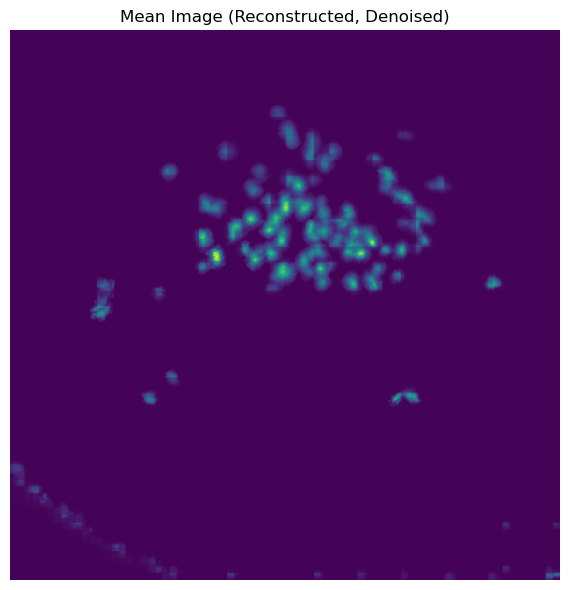

In [7]:
mean_img = Y_rec.mean(axis=0)

plt.figure(figsize=(6,6))
plt.imshow(mean_img)
plt.title("Mean Image (Reconstructed, Denoised)")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "01_mean_reconstructed.png"), dpi=200)
plt.show()


Using 117 accepted components


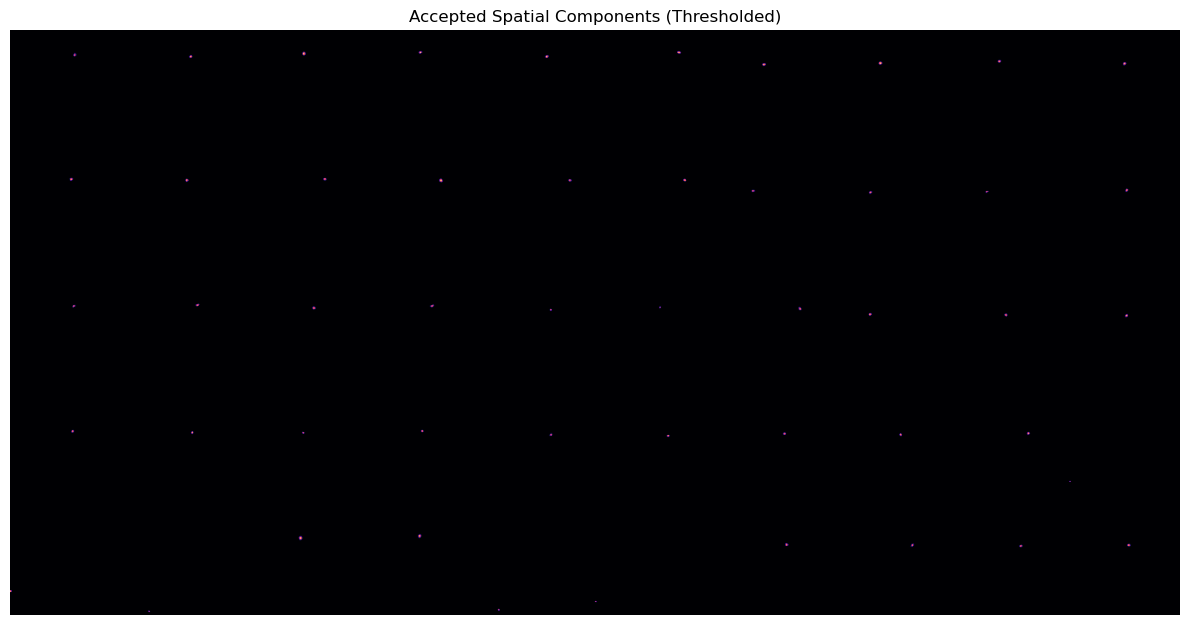

In [8]:
# -------------------------------------------------
# Clean spatial montage (accepted + thresholded)
# -------------------------------------------------

A = cnm.estimates.A

# Use only accepted components
if hasattr(cnm.estimates, "idx_components") and cnm.estimates.idx_components is not None:
    good_idx = np.array(cnm.estimates.idx_components)
else:
    good_idx = np.arange(A.shape[1])

print("Using", len(good_idx), "accepted components")

d1, d2 = cnm.dims

def clean_montage(A, dims, idx_list, ncols=10, thr_percentile=99):
    d1, d2 = dims
    n_show = len(idx_list)
    
    imgs = []
    for k in idx_list:
        ak = A[:, k].toarray().reshape((d1, d2), order="F")
        
        # threshold small values
        thr = np.percentile(ak, thr_percentile)
        ak[ak < thr] = 0
        
        # normalize
        if ak.max() > 0:
            ak = ak / ak.max()
            
        imgs.append(ak)
    
    imgs = np.array(imgs)
    
    nrows = int(np.ceil(n_show / ncols))
    canvas = np.zeros((nrows*d1, ncols*d2))
    
    for i in range(n_show):
        r, c = divmod(i, ncols)
        canvas[r*d1:(r+1)*d1, c*d2:(c+1)*d2] = imgs[i]
        
    return canvas

mont = clean_montage(A, cnm.dims, good_idx[:50])

plt.figure(figsize=(12,8))
plt.imshow(mont, cmap="magma")
plt.title("Accepted Spatial Components (Thresholded)")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "02_spatial_montage_clean.png"), dpi=200)
plt.show()


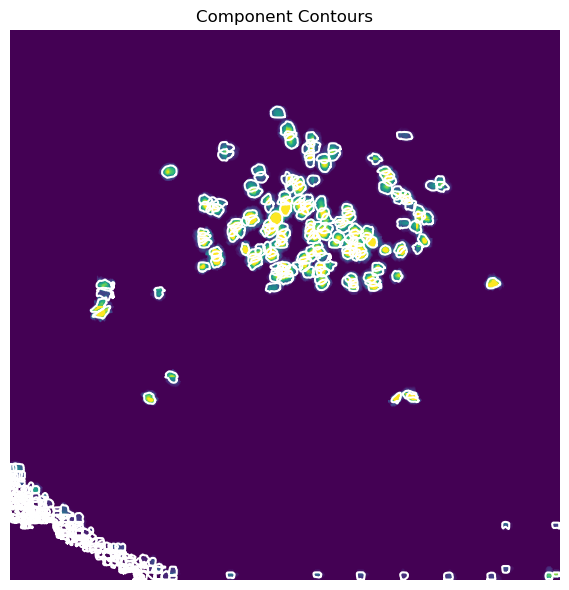

In [9]:
if HAS_CONTOURS:
    plt.figure(figsize=(6,6))
    plt.imshow(mean_img)
    plot_contours(A, mean_img, thr=0.9, display_numbers=False)
    plt.title("Component Contours")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "03_contours.png"), dpi=200)
    plt.show()
else:
    print("plot_contours not available in this CaImAn installation.")


Plotting 117 accepted components


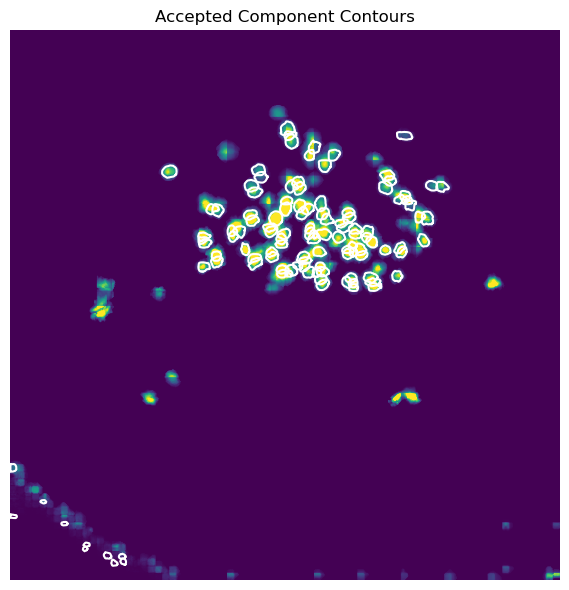

In [10]:
# -------------------------------------------------
# Contours: ONLY accepted components
# -------------------------------------------------

if HAS_CONTOURS:

    if hasattr(cnm.estimates, "idx_components") and cnm.estimates.idx_components is not None:
        good_idx = np.array(cnm.estimates.idx_components)
        print(f"Plotting {len(good_idx)} accepted components")
    else:
        print("No idx_components found. Plotting all components.")
        good_idx = np.arange(A.shape[1])

    # Select only accepted components
    A_good = A[:, good_idx]

    plt.figure(figsize=(6,6))
    plt.imshow(mean_img, cmap='gray')
    plot_contours(A_good, mean_img, thr=0.9, display_numbers=False)
    plt.title("Accepted Component Contours")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "03_contours_accepted.png"), dpi=200)
    plt.show()

else:
    print("plot_contours not available in this CaImAn installation.")


Plotting 385 rejected components


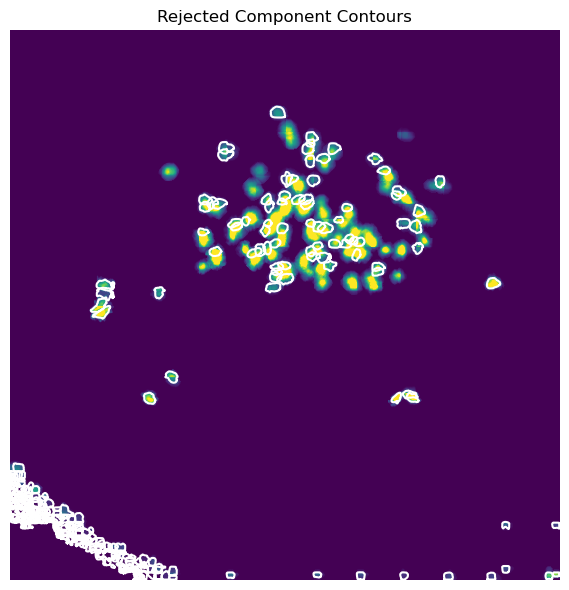

In [11]:
# -------------------------------------------------
# Contours: ONLY rejected components
# -------------------------------------------------

if HAS_CONTOURS:

    if hasattr(cnm.estimates, "idx_components_bad") and cnm.estimates.idx_components_bad is not None:
        bad_idx = np.array(cnm.estimates.idx_components_bad)
        print(f"Plotting {len(bad_idx)} rejected components")
    else:
        print("No idx_components_bad found. Nothing to plot.")
        bad_idx = []

    if len(bad_idx) > 0:

        # Select only rejected components
        A_bad = A[:, bad_idx]

        plt.figure(figsize=(6,6))
        plt.imshow(mean_img, cmap='gray')
        plot_contours(A_bad, mean_img, thr=0.9, display_numbers=False)
        plt.title("Rejected Component Contours")
        plt.axis("off")
        plt.tight_layout()
        plt.savefig(os.path.join(OUTDIR, "03_contours_rejected.png"), dpi=200)
        plt.show()
    else:
        print("No rejected components available.")

else:
    print("plot_contours not available in this CaImAn installation.")


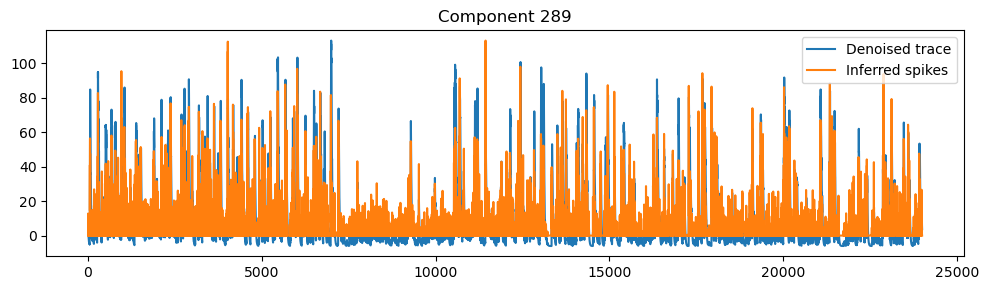

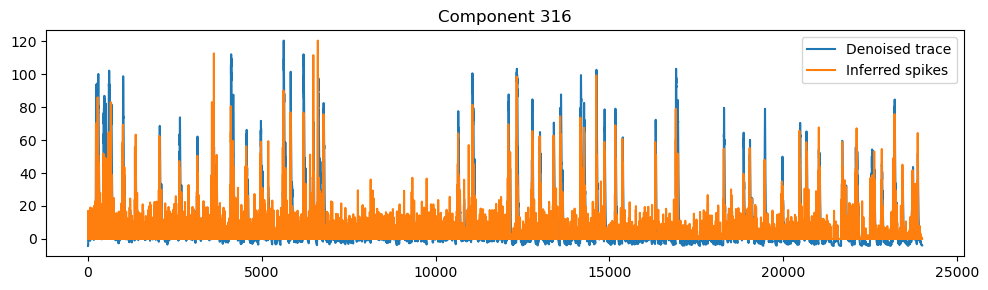

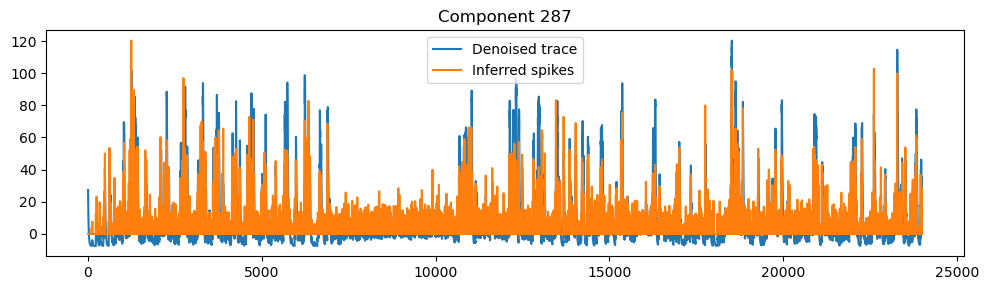

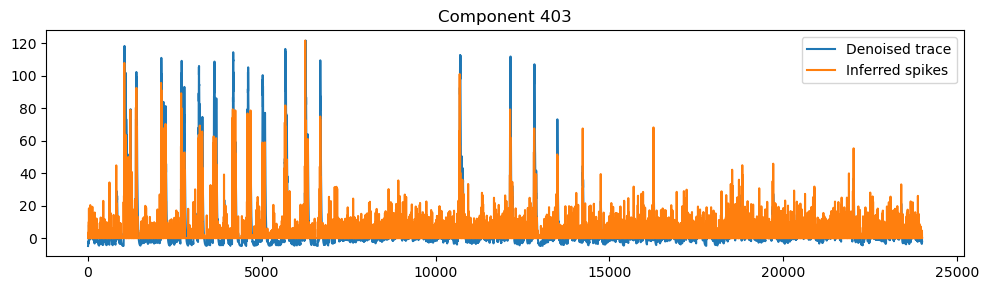

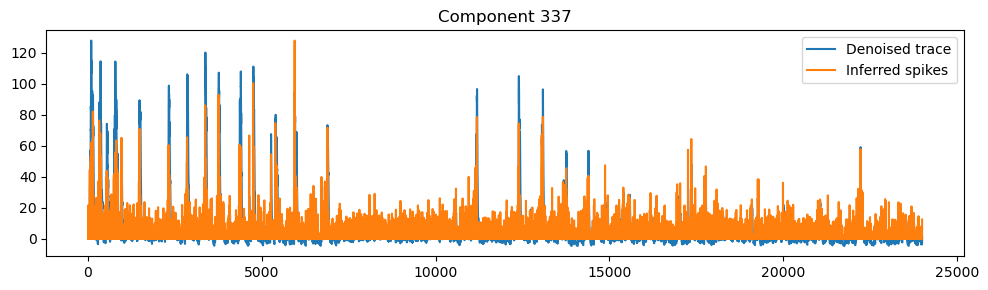

In [12]:
C = cnm.estimates.C
S = getattr(cnm.estimates, "S", None)

energy = C.var(axis=1)
idx = np.argsort(-energy)[:5]

for k in idx:
    plt.figure(figsize=(10,3))
    plt.plot(C[k], label="Denoised trace")
    if S is not None and np.max(S[k]) > 0:
        s_scaled = S[k] / np.max(S[k]) * np.max(C[k])
        plt.plot(s_scaled, label="Inferred spikes")
    plt.title(f"Component {k}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"04_trace_{k}.png"), dpi=200)
    plt.show()


In [13]:
# C = cnm.estimates.C
# S = getattr(cnm.estimates, "S", None)

# energy = C.var(axis=1)
# idx = np.argsort(-energy)[:5]

# t0 = 0
# t1 = 1000

# for k in idx:
#     plt.figure(figsize=(10,3))

#     if S is not None and np.max(S[k, t0:t1]) > 0:
#         s_window = S[k, t0:t1]
#         s_scaled = s_window / np.max(s_window) * np.max(trace)
#         plt.plot(s_scaled, label="Inferred spikes")
    
#     trace = C[k, t0:t1]
#     plt.plot(trace, label="Denoised trace")
    
    
#     plt.title(f"Component {k} (Frames {t0}-{t1})")
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig(os.path.join(OUTDIR, f"04_trace_{k}_{t0}_{t1}.png"), dpi=200)
#     plt.show()


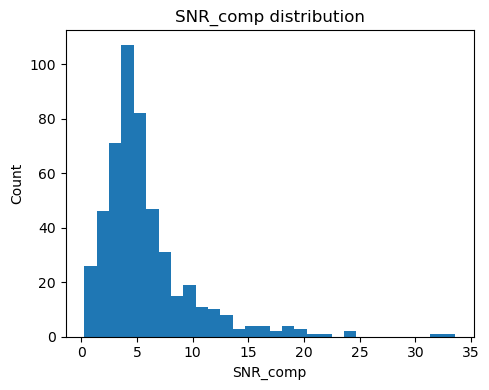

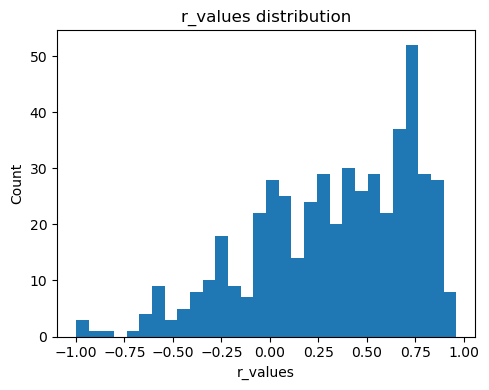

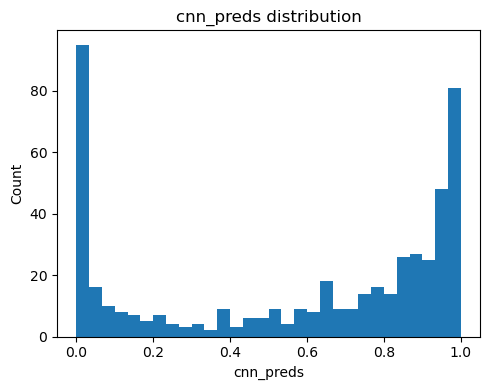

In [14]:
qc_fields = ["SNR_comp", "r_values", "cnn_preds"]

for field in qc_fields:
    if hasattr(cnm.estimates, field):

        vals = np.array(getattr(cnm.estimates, field)).ravel()

        # Keep only finite values
        vals = vals[np.isfinite(vals)]

        if len(vals) == 0:
            print(f"{field}: no finite values found.")
            continue

        plt.figure(figsize=(5,4))
        plt.hist(vals, bins=30)
        plt.title(f"{field} distribution")
        plt.xlabel(field)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.savefig(os.path.join(OUTDIR, f"05_hist_{field}.png"), dpi=200)
        plt.show()


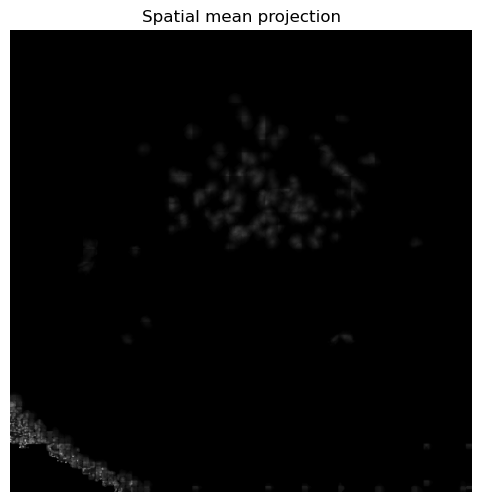

In [15]:
# Fast background image from spatial components only
A = cnm.estimates.A
d1, d2 = cnm.dims

mean_img = np.array(A.mean(axis=1)).reshape((d1, d2), order="F")

plt.figure(figsize=(6,6))
plt.imshow(mean_img, cmap='gray')
plt.title("Spatial mean projection")
plt.axis("off")
plt.show()

correlation_image = mean_img


In [16]:
import copy

cnm_view = copy.deepcopy(cnm)

cnm_view.estimates.select_components(
    use_object=True,
    save_discarded_components=True
)

cnm_view.estimates.nb_view_components(
    img=correlation_image,
    denoised_color='red',
    cmap='gray'
)


In [17]:
cnm_view.estimates.nb_view_components(
    img=correlation_image,
    denoised_color='red',
    cmap='gray'
)


In [18]:
import copy

cnm_all = copy.deepcopy(cnm)      # contains all components


In [19]:
good_idx = cnm_all.estimates.idx_components

cnm_good = copy.deepcopy(cnm_all)
cnm_good.estimates.select_components(
    idx_components=good_idx,
    use_object=True,
    save_discarded_components=False
)

cnm_good.estimates.nb_view_components(
    img=correlation_image,
    denoised_color='red',
    cmap='gray'
)

In [20]:
bad_idx = cnm_all.estimates.idx_components_bad

cnm_bad = copy.deepcopy(cnm_all)
cnm_bad.estimates.select_components(
    idx_components=bad_idx,
    use_object=True,
    save_discarded_components=False
)


In [21]:
cnm_bad.estimates.nb_view_components(
    img=correlation_image,
    denoised_color='red',
    cmap='gray'
)

In [22]:
bad_idx

array([  0,   1,   4,   5,   6,   8,  11,  12,  14,  15,  16,  17,  18,
        24,  26,  27,  28,  29,  30,  33,  34,  36,  40,  42,  43,  44,
        45,  48,  49,  53,  55,  56,  57,  58,  60,  61,  63,  64,  65,
        66,  67,  69,  70,  74,  81,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 129, 130,
       131, 132, 133, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144,
       145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157,
       158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170,
       171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183,
       184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196,
       197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209,
       210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 22

In [23]:
estimates.idx_components

NameError: name 'estimates' is not defined